In [2]:
import pandas as pd
import numpy as np

metadata = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/metadata.tsv", sep="\t")
mtb = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.tsv", sep="\t")
df = metadata.merge(mtb, on="Sample")

feature_cols = [c for c in mtb.columns if c != "Sample"]
feat = df[feature_cols].copy()
meta = df[["Sample", "Study.Group"]].copy()
label = df["Study.Group"]

print("Feature matrix shape:", feat.shape)
print("Labels:", label.value_counts())

Feature matrix shape: (220, 8848)
Labels: Study.Group
CD         88
UC         76
Control    56
Name: count, dtype: int64


In [3]:
# SIAMCAT original: filter.features()
# Removes features that are essentially absent across most samples —
# same purpose as prevalence filtering elsewhere: reduces noise from
# metabolites that were barely detected and can't carry real signal.
# SIAMCAT's default filter method is "abundance" with a cutoff, but the
# most common one used in practice is a simple prevalence threshold —
# keep features present (non-zero) in at least a minimum fraction of samples.

prevalence = (feat > 0).mean(axis=0)
keep_cols = prevalence[prevalence >= 0.10].index  # SIAMCAT's typical default cutoff is 10%
feat_filtered = feat[keep_cols]

print("Features before filtering:", feat.shape[1])
print("Features after filtering:", feat_filtered.shape[1])

Features before filtering: 8848
Features after filtering: 8847


In [4]:
# SIAMCAT original: normalize.features(norm.method = "log.unit", ...)
# "log.unit" does two things: (1) log-transforms the values (same purpose
# as before — fixes skewed abundance data), then (2) scales each sample's
# feature values so they sum to a consistent "unit" total — this corrects
# for samples having different overall signal intensity/sequencing depth.

log_n0 = 1e-6  # small pseudocount SIAMCAT adds before log, avoids log(0)
feat_log = np.log10(feat_filtered + log_n0)

# unit-scale each sample (row) so it sums to 1 — the "unit" part of log.unit
feat_norm = feat_log.div(feat_log.sum(axis=1), axis=0)

print("Shape after normalization:", feat_norm.shape)
print(feat_norm.iloc[:3, :5])

Shape after normalization: (220, 8847)
   C18-neg_Cluster_0001: NA  C18-neg_Cluster_0002: NA  \
0                 -0.004951                  0.003140   
1                  0.001765                  0.000790   
2                 -0.003988                  0.002604   

   C18-neg_Cluster_0003: NA  C18-neg_Cluster_0004: 4-hydroxystyrene  \
0                  0.002030                                0.002295   
1                  0.000973                                0.001394   
2                  0.002584                                0.001005   

   C18-neg_Cluster_0005: NA  
0                  0.002789  
1                  0.001446  
2                  0.002591  


In [6]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

# SIAMCAT original: create.data.split() then train.model(method="lasso")
# LASSO logistic regression: a linear model that automatically shrinks
# irrelevant features' weights to exactly zero, effectively doing feature
# selection *during* training rather than as a separate step beforehand
# (unlike our IBDpred pipeline, which selected features first, then trained).
# This is SIAMCAT's main/default method.

le = LabelEncoder()
y_enc = le.fit_transform(label)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LogisticRegressionCV with l1 penalty = LASSO logistic regression,
# with built-in cross-validated selection of regularization strength
lasso = LogisticRegressionCV(
    penalty="l1", solver="liblinear", cv=5, max_iter=5000, random_state=42
)

# Binary task first (IBD vs Control), matching SIAMCAT's typical binary framing
y_binary = label.map(lambda g: "Control" if g == "Control" else "IBD")
y_bin_enc = LabelEncoder().fit_transform(y_binary)

probs = cross_val_predict(lasso, feat_norm, y_bin_enc, cv=cv, method="predict_proba")[:, 1]
auc = roc_auc_score(y_bin_enc, probs)

print(f"SIAMCAT-style LASSO, binary IBD vs Control, macro-AUC: {auc:.3f}")

SIAMCAT-style LASSO, binary IBD vs Control, macro-AUC: 0.666


In [8]:
from sklearn.ensemble import RandomForestClassifier

# SIAMCAT original: train.model(siamcat, method="randomForest")
# Same idea as before, but using Random Forest instead of LASSO — no
# convergence issues since RF doesn't rely on iterative optimization
# the way linear models do, so this should run quickly.

rf_siamcat = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
probs_rf_fs = cross_val_predict(rf_siamcat, feat_norm_fs, y_bin_enc, cv=cv, method="predict_proba")[:, 1]
auc_rf_fs = roc_auc_score(y_bin_enc, probs_rf_fs)

print(f"SIAMCAT-style Random Forest with AUC feature selection (top 100), macro-AUC: {auc_rf_fs:.3f}")

SIAMCAT-style Random Forest with AUC feature selection (top 100), macro-AUC: 0.919


In [9]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# SIAMCAT original: check.associations(siamcat, sort.by='fc', alpha=0.05,
#                                       mult.corr="fdr", plot.type="quantile.box",
#                                       panels=c("fc", "prevalence", "auroc"))
# For each feature, this computes THREE things per SIAMCAT's own panel design:
#  1. fc = fold change between groups (effect size/direction)
#  2. prevalence = % of samples where the feature is detected
#  3. auroc = how well this single feature alone separates the two classes
# Plus a significance test (Wilcoxon/Mann-Whitney, since SIAMCAT defaults to
# a non-parametric test for microbial abundance data) with FDR correction
# for testing thousands of features at once.

results = []
groups = y_binary.unique()  # "IBD" vs "Control", from earlier
g1_mask = (y_binary == groups[0]).values
g2_mask = (y_binary == groups[1]).values

for col in feat_norm.columns:
    x1 = feat_norm.loc[g1_mask, col]
    x2 = feat_norm.loc[g2_mask, col]
    try:
        stat, pval = mannwhitneyu(x1, x2)
    except ValueError:
        pval = 1.0
    fc = x1.mean() - x2.mean()  # fold change (already log-scale, so this is a log-fold-change)
    prevalence_feat = (feat_filtered[col] > 0).mean() if col in feat_filtered.columns else np.nan
    try:
        auroc = roc_auc_score(g1_mask.astype(int), feat_norm[col])
    except ValueError:
        auroc = np.nan
    results.append({"feature": col, "pval": pval, "fold_change": fc,
                     "prevalence": prevalence_feat, "auroc": auroc})

assoc_df = pd.DataFrame(results)
assoc_df["fdr"] = multipletests(assoc_df["pval"], method="fdr_bh")[1]
assoc_df_sorted = assoc_df.sort_values("fdr")

print("Total features tested:", len(assoc_df))
print("Significant at FDR < 0.05:", (assoc_df["fdr"] < 0.05).sum())
print("\nTop 10 most significant features:")
print(assoc_df_sorted.head(10))

Total features tested: 8847
Significant at FDR < 0.05: 4278

Top 10 most significant features:
                         feature          pval  fold_change  prevalence  \
6016  HILIC-neg_Cluster_1401: NA  2.363541e-07     0.008669    0.495455   
6051  HILIC-neg_Cluster_1436: NA  1.533889e-07     0.008860    0.381818   
513     C18-neg_Cluster_0514: NA  9.666692e-07     0.008542    0.340909   
7844  HILIC-pos_Cluster_1373: NA  8.863501e-07     0.005377    0.263636   
4313     C8-pos_Cluster_2137: NA  1.397511e-06     0.008242    0.250000   
6954  HILIC-pos_Cluster_0483: NA  1.847441e-06     0.008304    0.368182   
7909  HILIC-pos_Cluster_1439: NA  2.160249e-06     0.008838    0.327273   
1730    C18-neg_Cluster_1731: NA  3.393746e-06     0.008142    0.340909   
2858     C8-pos_Cluster_0682: NA  3.353997e-06     0.009348    0.327273   
6539  HILIC-pos_Cluster_0068: NA  3.199417e-06     0.009449    0.409091   

         auroc       fdr  
6016  0.731490  0.001046  
6051  0.735083  0.001046 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# SIAMCAT original: train.model(method="enet") and train.model(method="ridge")
# Elastic Net: combines L1 (feature-zeroing) and L2 (shrinkage) penalties —
# a middle ground between LASSO (pure L1) and Ridge (pure L2)
# Ridge: pure L2 penalty — shrinks all coefficients toward zero but never
# exactly to zero, so it keeps every feature rather than selecting a subset

# Elastic Net
enet = LogisticRegression(penalty="elasticnet", solver="saga", max_iter=20000, random_state=42)
enet_grid = GridSearchCV(enet, {"C": [0.01, 0.1, 1, 10], "l1_ratio": [0.1, 0.5, 0.9]}, cv=5, scoring="roc_auc")
probs_enet = cross_val_predict(enet_grid, feat_norm_fs, y_bin_enc, cv=cv, method="predict_proba")[:, 1]
auc_enet = roc_auc_score(y_bin_enc, probs_enet)

# Ridge
ridge = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=20000, random_state=42)
ridge_grid = GridSearchCV(ridge, {"C": [0.01, 0.1, 1, 10]}, cv=5, scoring="roc_auc")
probs_ridge = cross_val_predict(ridge_grid, feat_norm_fs, y_bin_enc, cv=cv, method="predict_proba")[:, 1]
auc_ridge = roc_auc_score(y_bin_enc, probs_ridge)

print(f"SIAMCAT-style Elastic Net (top 100 features), macro-AUC: {auc_enet:.3f}")
print(f"SIAMCAT-style Ridge (top 100 features), macro-AUC: {auc_ridge:.3f}")

SIAMCAT-style Elastic Net (top 100 features), macro-AUC: 0.720
SIAMCAT-style Ridge (top 100 features), macro-AUC: 0.689


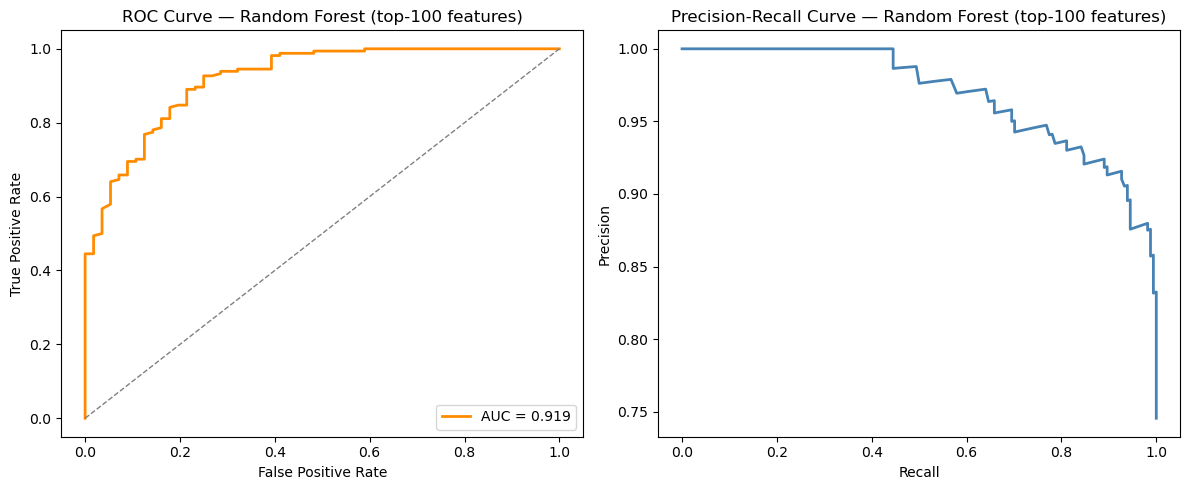

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# SIAMCAT original: model.evaluation.plot()
# Produces ROC and PR curves across CV folds, plus the mean curve.
# Here we plot it for the Random Forest model (your best result, AUC=0.919).

fpr, tpr, _ = roc_curve(y_bin_enc, probs_rf_fs)
precision, recall, _ = precision_recall_curve(y_bin_enc, probs_rf_fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc_rf_fs:.3f}")
axes[0].plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Random Forest (top-100 features)")
axes[0].legend(loc="lower right")

# Precision-Recall curve
axes[1].plot(recall, precision, color="steelblue", lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Random Forest (top-100 features)")

plt.tight_layout()
plt.savefig("siamcat_rf_roc_pr_curve.png", dpi=150)
plt.show()

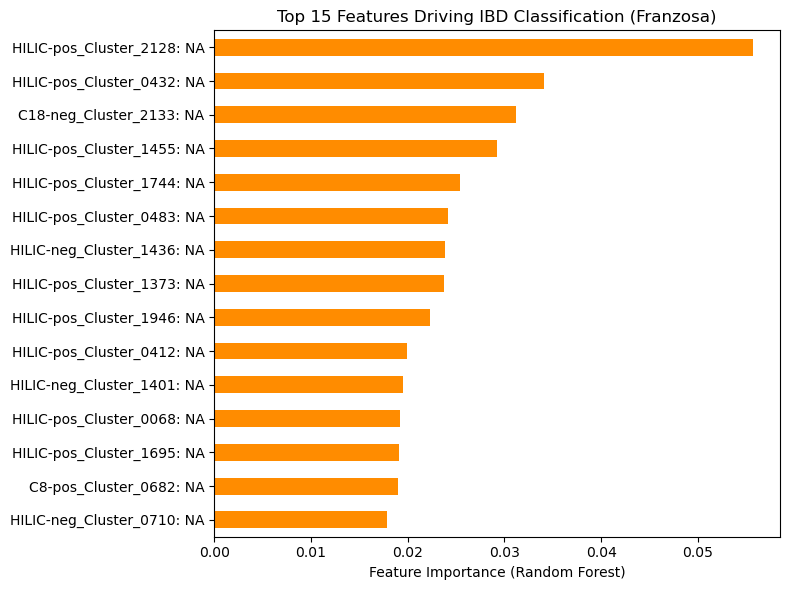

HILIC-pos_Cluster_2128: NA    0.055696
HILIC-pos_Cluster_0432: NA    0.034042
C18-neg_Cluster_2133: NA      0.031220
HILIC-pos_Cluster_1455: NA    0.029201
HILIC-pos_Cluster_1744: NA    0.025445
HILIC-pos_Cluster_0483: NA    0.024167
HILIC-neg_Cluster_1436: NA    0.023850
HILIC-pos_Cluster_1373: NA    0.023704
HILIC-pos_Cluster_1946: NA    0.022345
HILIC-pos_Cluster_0412: NA    0.019953
HILIC-neg_Cluster_1401: NA    0.019481
HILIC-pos_Cluster_0068: NA    0.019156
HILIC-pos_Cluster_1695: NA    0.019087
C8-pos_Cluster_0682: NA       0.018965
HILIC-neg_Cluster_0710: NA    0.017885
dtype: float64


In [12]:
# SIAMCAT original: model.interpretation.plot()
# Shows which features the model relied on most — for Random Forest,
# this is "feature importance" (how much each feature reduced impurity
# across all trees), the RF equivalent of SIAMCAT's "model weights."
# We need to fit the model on the full data once (not just CV predictions)
# to extract these importances.

rf_final = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_final.fit(feat_norm_fs, y_bin_enc)

importances = pd.Series(rf_final.feature_importances_, index=feat_norm_fs.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh", color="darkorange")
plt.xlabel("Feature Importance (Random Forest)")
plt.title("Top 15 Features Driving IBD Classification (Franzosa)")
plt.tight_layout()
plt.savefig("siamcat_rf_feature_importance.png", dpi=150)
plt.show()

print(top15)